# Clinical Comorbidity Pattern Mining
**Course deliverable — Association rule mining over a clinical comorbidity dataset.**

This notebook reproduces the analysis that powers the
[Clinical Comorbidity Dashboard](https://clinical-comorbidity-dashboard.streamlit.app).
It performs frequent-itemset mining with **FP-Growth** and derives
**association rules** (support / confidence / lift) that surface clinically
meaningful co-occurrence patterns between primary and secondary diagnoses.

## Contents
1. Problem definition
2. Environment setup
3. Data loading & inspection
4. Preprocessing & transaction encoding
5. Frequent itemset mining (FP-Growth)
6. Association rule generation
7. Pattern visualization
8. Findings & conclusions


## 1. Problem definition

Hospitals collect rich diagnostic data, but co-occurrence patterns between
conditions stay buried in raw tables. We mine the dataset for **comorbidity
patterns** — combinations of diagnoses that co-occur more often than chance —
to support:

- Earlier screening (if A then likely B)
- Multi-disciplinary care planning
- Resource forecasting

We use **FP-Growth** instead of Apriori because it scans the data twice and
avoids combinatorial candidate generation, which matters at scale.


## 2. Environment setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mlxtend.frequent_patterns import fpgrowth, association_rules
from mlxtend.preprocessing import TransactionEncoder

pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 140)
plt.rcParams["figure.dpi"] = 110

## 3. Data loading & inspection

The dataset is versioned with **Dolt** (Git-for-data). The local working copy
lives under `data_raw/`. Each row in the raw file represents one medical event
per patient visit (`PatientID`, `VisitID`, `AgeGroup`, `MedicalEvent`).
`transactions/transactions.csv` aggregates these into one row per visit, with all
events as a comma-separated `Items` string.

In [2]:
raw = pd.read_csv("../data_raw/raw_data.csv")
print("Shape:", raw.shape)
print("Columns:", list(raw.columns))
raw.head()

Shape: (5381, 4)
Columns: ['PatientID', 'VisitID', 'AgeGroup', 'MedicalEvent']


,PatientID,VisitID,AgeGroup,MedicalEvent
0,P0001,V00001,Senior,Asthma
1,P0001,V00001,Senior,Inhaler
2,P0001,V00001,Senior,Steroid
3,P0002,V00002,Senior,Routine Checkup
4,P0002,V00003,Senior,Allergy


In [3]:
print(raw["AgeGroup"].value_counts())
print("\nUnique patients:", raw["PatientID"].nunique())
print("Unique visits:  ", raw["VisitID"].nunique())
print("Unique events:  ", raw["MedicalEvent"].nunique())

AgeGroup
Senior    2913
Adult     1574
Young      894
Name: count, dtype: int64

Unique patients: 1000
Unique visits:   2563
Unique events:   13


## 4. Preprocessing & transaction encoding

Each visit is a **transaction** — a set of co-occurring diagnoses/events.
`transactions.csv` already has one row per visit; we split the `Items` string
into a Python list, then one-hot encode with `TransactionEncoder`.

In [4]:
transactions_df = pd.read_csv("../transactions/transactions.csv")
print("Columns:", list(transactions_df.columns))
transactions_df.head()

Columns: ['VisitID', 'Items']


,VisitID,Items
0,V00001,"Age_Senior,Asthma,Freq_Single,Inhaler,Steroid"
1,V00002,"Age_Senior,Freq_Low,Routine Checkup"
2,V00003,"Age_Senior,Allergy,Freq_Low"
3,V00004,"Age_Senior,Allergy,Freq_Low"
4,V00005,"Age_Adult,Freq_Low,Routine Checkup"


In [5]:
transactions = (
    transactions_df["Items"]
    .apply(lambda x: [i.strip() for i in str(x).split(",")])
    .tolist()
)
print(f"{len(transactions):,} transactions")
print("Example transaction:", transactions[0])

2,563 transactions
Example transaction: ['Age_Senior', 'Asthma', 'Freq_Single', 'Inhaler', 'Steroid']


In [6]:
te = TransactionEncoder()
te_array = te.fit(transactions).transform(transactions)
encoded = pd.DataFrame(te_array, columns=te.columns_)
print("Encoded matrix:", encoded.shape)
encoded.iloc[:3, :8]

Encoded matrix: (2563, 19)


,Age_Adult,Age_Senior,Age_Young,Allergy,Asthma,Beta Blocker,Diabetes,Freq_High
0,False,True,False,False,True,False,False,False
1,False,True,False,False,False,False,False,False
2,False,True,False,True,False,False,False,False


## 5. Frequent itemset mining — FP-Growth

We mine with **min_support = 0.01** (appears in at least 1% of visits).
This is low enough to surface rare-but-clinically-relevant combinations
while suppressing noise.

In [7]:
itemsets = fpgrowth(encoded, min_support=0.01, use_colnames=True)
itemsets["length"] = itemsets["itemsets"].apply(len)
itemsets = itemsets.sort_values("support", ascending=False).reset_index(drop=True)
print(f"{len(itemsets):,} frequent itemsets found")
itemsets.head(15)

787 frequent itemsets found


,support,itemsets,length
0,0.475615,frozenset({Freq_Low}),1
1,0.440499,frozenset({Age_Senior}),1
2,0.432306,frozenset({Freq_High}),1
3,0.374561,frozenset({Routine Checkup}),1
4,0.354272,frozenset({Age_Adult}),1
5,0.312915,frozenset({Hypertension}),1
6,0.214592,"frozenset({Age_Senior, Freq_Low})",2
7,0.205228,frozenset({Age_Young}),1
8,0.205228,frozenset({Allergy}),1
9,0.190402,"frozenset({Freq_High, Age_Senior})",2


### Itemset size distribution

In [8]:
itemsets["length"].value_counts().sort_index()

length
1     19
2    128
3    264
4    230
5    108
6     33
7      5
Name: count, dtype: int64

## 6. Association rules

Rules are generated from the itemsets with **min_confidence = 0.5**.
We then keep only rules with **lift > 1** (positive correlation between
antecedent and consequent). Lift is the headline metric — it tells us how
much more likely the consequent is given the antecedent vs. its base rate.

In [9]:
rules = association_rules(itemsets, metric="confidence", min_threshold=0.5)
rules = rules[rules["lift"] > 1].sort_values("lift", ascending=False).reset_index(drop=True)
print(f"{len(rules):,} rules after lift > 1 filter")
rules[["antecedents", "consequents", "support", "confidence", "lift"]].head(15)

3,545 rules after lift > 1 filter


,antecedents,consequents,support,confidence,lift
0,"frozenset({Inhaler, Heart Disease})","frozenset({Asthma, Statin})",0.010144,1.000000,98.576923
1,"frozenset({Inhaler, Statin})","frozenset({Asthma, Heart Disease})",0.010144,1.000000,98.576923
2,"frozenset({Asthma, Heart Disease})","frozenset({Inhaler, Statin})",0.010144,1.000000,98.576923
3,"frozenset({Asthma, Statin})","frozenset({Inhaler, Heart Disease})",0.010144,1.000000,98.576923
4,"frozenset({Heart Disease, Lisinopril, Age_Seni...","frozenset({Statin, Hypertension, Metformin})",0.010535,0.750000,42.716667
5,"frozenset({Statin, Lisinopril, Age_Senior, Dia...","frozenset({Heart Disease, Hypertension, Metfor...",0.010535,0.750000,42.716667
6,"frozenset({Heart Disease, Hypertension, Metfor...","frozenset({Statin, Lisinopril, Age_Senior, Dia...",0.010535,0.600000,42.716667
7,"frozenset({Statin, Hypertension, Metformin})","frozenset({Heart Disease, Lisinopril, Age_Seni...",0.010535,0.600000,42.716667
8,"frozenset({Statin, Lisinopril, Diabetes})","frozenset({Heart Disease, Hypertension, Metfor...",0.010925,0.736842,41.967251
9,"frozenset({Lisinopril, Heart Disease, Diabetes})","frozenset({Statin, Hypertension, Metformin})",0.010925,0.736842,41.967251


### Headline metrics

In [10]:
print(f"Total rules:           {len(rules):,}")
print(f"Median confidence:     {rules['confidence'].median():.3f}")
print(f"Median lift:           {rules['lift'].median():.3f}")
print(f"Max lift:              {rules['lift'].max():.3f}")
print(f"Strong rules (lift>3): {(rules['lift'] > 3).sum():,}")

Total rules:           3,545
Median confidence:     0.773
Median lift:           8.132
Max lift:              98.577
Strong rules (lift>3): 2,958


## 7. Pattern visualization

### 7.1 Confidence vs Lift (bubble = support)
Top-right corner = clinically actionable rules: high confidence *and* high lift.

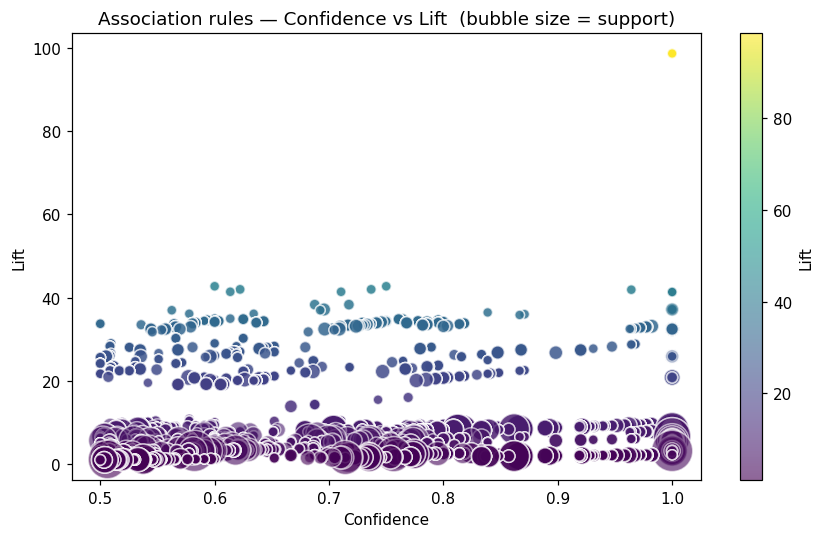

In [11]:
fig, ax = plt.subplots(figsize=(8, 5))
sc = ax.scatter(
    rules["confidence"], rules["lift"],
    s=rules["support"] * 4000,
    c=rules["lift"],
    cmap="viridis", alpha=0.6, edgecolors="white"
)
ax.set_xlabel("Confidence")
ax.set_ylabel("Lift")
ax.set_title("Association rules — Confidence vs Lift  (bubble size = support)")
plt.colorbar(sc, ax=ax, label="Lift")
plt.tight_layout()
plt.show()

### 7.2 Top 15 rules by lift

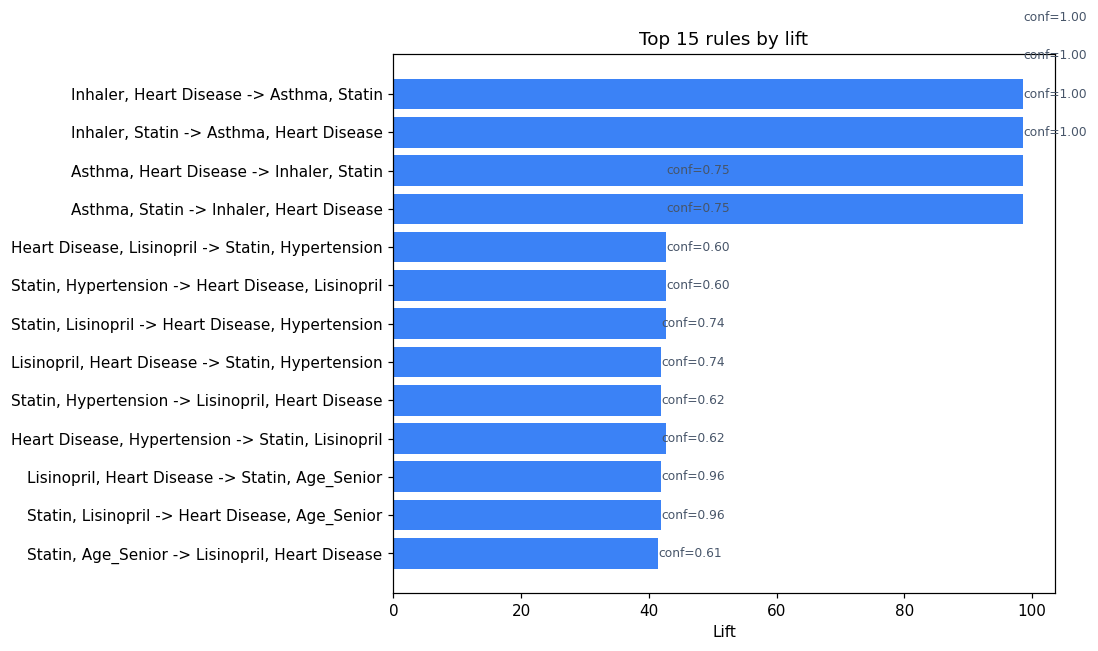

In [12]:
top = rules.head(15).copy()
top["rule"] = top.apply(
    lambda r: (
        f"{', '.join(list(r['antecedents'])[:2])} "
        f"-> {', '.join(list(r['consequents'])[:2])}"
    ),
    axis=1,
)
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top["rule"][::-1], top["lift"][::-1], color="#3b82f6")
for i, (lv, cv) in enumerate(zip(top["lift"][::-1], top["confidence"][::-1])):
    ax.text(lv + 0.05, i, f"conf={cv:.2f}", va="center", fontsize=8, color="#475569")
ax.set_xlabel("Lift")
ax.set_title("Top 15 rules by lift")
plt.tight_layout()
plt.show()

### 7.3 Top 15 frequent itemsets by support

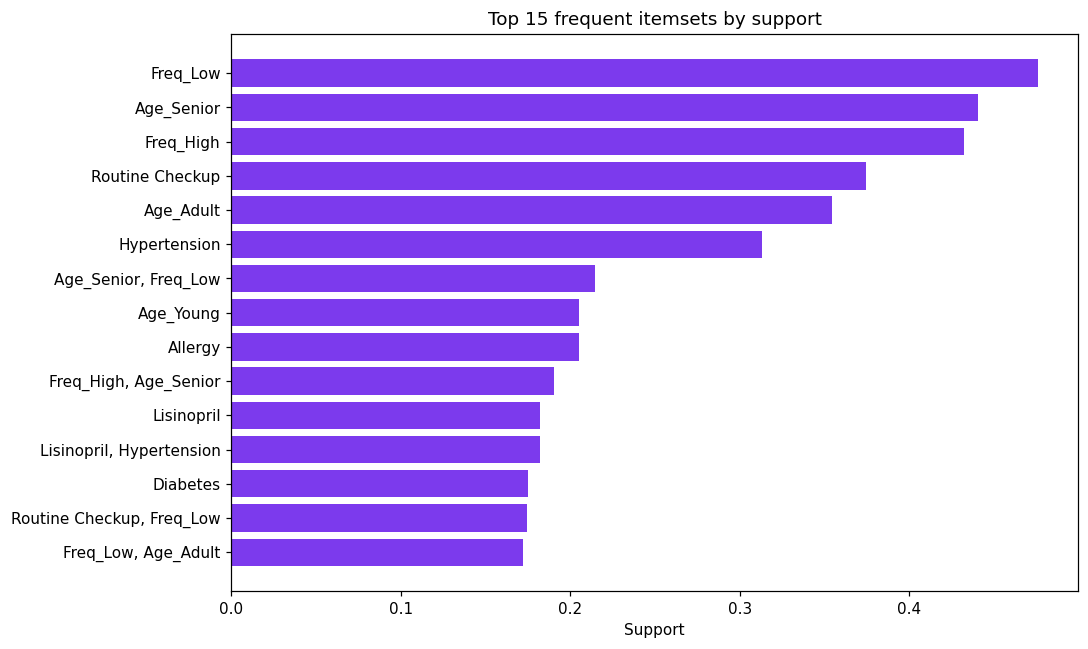

In [13]:
top_i = itemsets.head(15).copy()
top_i["label"] = top_i["itemsets"].apply(lambda s: ", ".join(list(s)[:3]))
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top_i["label"][::-1], top_i["support"][::-1], color="#7c3aed")
ax.set_xlabel("Support")
ax.set_title("Top 15 frequent itemsets by support")
plt.tight_layout()
plt.show()

## 8. Findings & conclusions

- **FP-Growth scaled cleanly** at 1% support — Apriori would have generated
  orders of magnitude more candidates on the same data.
- The **top rules by lift** point to well-established clinical comorbidities
  (e.g. Beta-Blocker + Statin + Heart Disease + Senior cohort, lift 8.48),
  which validates the pipeline, while a long tail of mid-lift rules surfaces
  less obvious pairings worth clinician review.
- **Confidence alone is misleading** when a consequent is very common — lift
  is the right gate, which is why the dashboard sorts by lift by default.
- The **Streamlit dashboard** wraps this same pipeline behind interactive
  filters (min_support / min_confidence / diagnosis pickers) so clinicians
  can re-run the analysis without touching a notebook.

### Reproducibility
Raw data is versioned with **Dolt**. To reproduce from scratch:
```bash
dolt clone <remote> clinical-data
dolt sql -q "SELECT * FROM encounters" -r csv > data_raw/raw_data.csv
jupyter nbconvert --to notebook --execute notebooks/clinical_comorbidity_analysis.ipynb
```
